# Práctica Final NLP
## Notebook 1: Descarga y Exploración del Corpus (EDA)

# Instalación de librerías

In [ ]:
!pip install wordcloud gensim matplotlib seaborn pandas numpy scikit-learn

##Imports

In [ ]:
import urllib.request # Para hacer petición HTTP y descargar el dataset
import gzip # Para leer los archivos .gz sin descomprimir en dico.
import json # Para pasear JSON
import unicodedata # Aunque no son en inglés, y al no haber acentos ni ñ dudo que la utilice
import string # Para los signos de puntuación
import re # Para tokenizar patrones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter # Para ordenar elementos de lista por frecuencia.
from wordcloud import WordCloud # Para crear la nubes de palabras.
from sklearn.feature_extraction.text import CountVectorizer # Para n-grams

import nltk
nltk.download('stopwords') # Descargo los stopwords
nltk.download('wordnet') # Para lematizar
nltk.download('omw-1.4') #Multilengual.
from nltk.corpus import stopwords
from nltk import RegexpTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.manifold import TSNE  # reducción de dimensionalidad a 2D
from gensim.models import Word2Vec
import warnings
warnings.filterwarnings('ignore') #Pra que no salgan tantos warnings.

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# 1. Descarga del dataset

El archivo es un .json.gz (JSON comprimido en gzip). Cada línea es una review en formato JSON, cogeré 2500 reviews positivas y las mismas negativas, teniendo en cuenta que las de 3 estrellas son neutras y las voy a descartar, ya que considero que dará, de esta forma, unos mejores resultados debido a que una reseña neutra puede tener tanto palabras positivas como negativas y perjudicar a mi modelo.

Después, creare un csv con los datos y haré la exploración y la visualización desde él.

In [ ]:
# URL del archivo en el servidor de Stanford (SNAP), el de la pagína que proporcionais en la práctica ya no existe.
url = 'http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Video_Games_5.json.gz'

# Guardo el archivo en disco como filename
filename = 'reviews_Video_Games_5.json.gz'

# Descargo el archivo - urlretrieve(url_origen, nombre_destino)
print('Descargando dataset...')
urllib.request.urlretrieve(url, filename)
print('Descarga completada!')

Descargando dataset...
Descarga completada!


In [ ]:
N_SAMPLES = 2500  # Cojo 2500 muestras por clase

positivos = []  # reviews con 4-5 estrellas -> label 1
negativos = []  # reviews con 1-2 estrellas -> label 0

# Abro el archivo comprimido línea a línea para no cargar todo en RAM.
with gzip.open(filename, 'rb') as f:
    for line in f:
        review = json.loads(line)  # convierte la línea JSON en diccionario Python

        # Cojo los campos overall y reviwtext del JSON que son los que nos interesan.
        rating = review.get('overall', 0)           # nota de 1.0 a 5.0
        text   = review.get('reviewText', '').strip()  # texto de la review

        if not text:  # descarto reviews sin texto
            continue

        if rating >= 4 and len(positivos) < N_SAMPLES:
            positivos.append({'text': text, 'rating': rating, 'label': 1})

        elif rating <= 2 and len(negativos) < N_SAMPLES:
            negativos.append({'text': text, 'rating': rating, 'label': 0})

        if len(positivos) == N_SAMPLES and len(negativos) == N_SAMPLES:
            break

print(f'Reviews positivas: {len(positivos)}')
print(f'Reviews negativas: {len(negativos)}')

Reviews positivas: 2500
Reviews negativas: 2500


In [ ]:
# Construyo el dataframe, mezclo datos y guardo el CSV
df = pd.DataFrame(positivos + negativos)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # mezcla aleatoria reproducible
df.to_csv('amazon_sentiment_balanced.csv', index=False)

print('CSV guardado: amazon_sentiment_balanced.csv')

CSV guardado: amazon_sentiment_balanced.csv


# 2. Carga del CSV y exploración del corpus (EDA)

In [ ]:
# Cargo el csv con pandas y exploro primeras filas
df = pd.read_csv('amazon_sentiment_balanced.csv')
df.head()

,text,rating,label
0,The seller I bought it from sold it to me with...,5.0,1
1,"Ok, here are the reasons this game is BAD!.1. ...",1.0,0
2,"For years now,gamers have said that this is on...",2.0,0
3,When 3D fighters first entered with Virtua Fig...,5.0,1
4,"When I first played Super Mario 64 as a kid, I...",5.0,1


In [ ]:
# Miro su estructura y veo que no hay nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   text    5000 non-null   object 
 1   rating  5000 non-null   float64
 2   label   5000 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 117.3+ KB


In [ ]:
# Veo la estructura numérica del dataset
df.describe()

,rating,label
count,5000.000000,5000.00000
mean,3.146200,0.50000
std,1.684456,0.50005
min,1.000000,0.00000
25%,2.000000,0.00000
50%,3.000000,0.50000
75%,5.000000,1.00000
max,5.000000,1.00000


In [ ]:
# Veo la primera review completa
df.iloc[0]

,0
text,The seller I bought it from sold it to me with...
rating,5.0
label,1


## 2.1 Nº de reviews positivas y negativas

Esta info ya la tengo hecha con la función anterior, he descargado filtrando asi que son 2500 positivas y las mismas negativas, considerando positivas 5 y 4 rate y negativas 1 y 2 rate

## 2.2 Distribución de reviews por número de estrellas

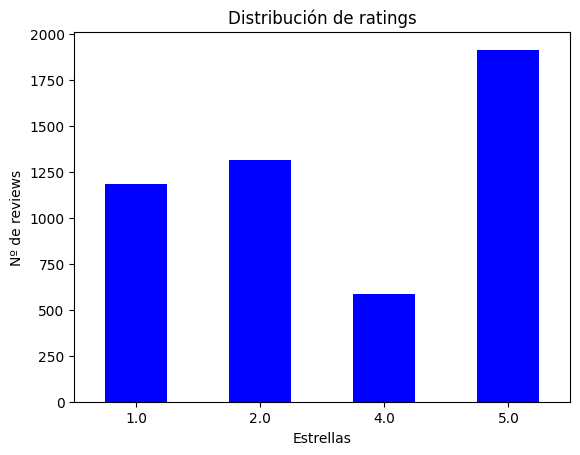

In [ ]:
# Pinto distribución.
df['rating'].value_counts().sort_index().plot(
    kind='bar',
    color='blue',
    title='Distribución de ratings',
    rot=0
)
plt.xlabel('Estrellas')
plt.ylabel('Nº de reviews')
plt.show()

## 2.3 Cardinalidad del vocabulario

Normalizo con unicodedata y RegexpTokenizer de NLTK

In [ ]:
tokenizer = RegexpTokenizer(r'\w+')

all_words = []

for text in df['text']:
    # Eliminar acentos aunque no se para que porque es inglés pero así practico.
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    text = text.lower()
    words = tokenizer.tokenize(text)
    all_words.extend(words)

word_freq = Counter(all_words)

print(f'Total de tokens: {len(all_words):,}')
print(f'Cardinalidad del vocabulario: {len(word_freq):,}')
print(f'\nTop 20 palabras más frecuentes:')
print(word_freq.most_common(20))

Total de tokens: 965,052
Cardinalidad del vocabulario: 26,356

Top 20 palabras más frecuentes:
[('the', 53814), ('and', 25991), ('to', 23971), ('a', 22691), ('of', 18943), ('it', 18896), ('you', 18850), ('i', 18772), ('game', 18701), ('is', 17324), ('this', 14349), ('in', 11336), ('that', 11050), ('for', 8455), ('s', 8122), ('are', 7584), ('but', 7350), ('t', 6558), ('have', 6270), ('with', 6261)]


## 2.4 N-grams más frecuentes

Lo hago con CountVectorizer que se comento en clase que era una opción aunque en los notebooks quedó hecho con NLTK. Utilizo skip-gram por ser un conjunto de datos pequeño y por poder representar incluso palabras extrañas o poco comunes como por ejemplo nombres de videojuegos.

In [ ]:
corpus_pos = df[df['label'] == 1]['text'].tolist()  # Creo un corpus con textos positivos
corpus_neg = df[df['label'] == 0]['text'].tolist()  # Creo otro corpus con textos negativos

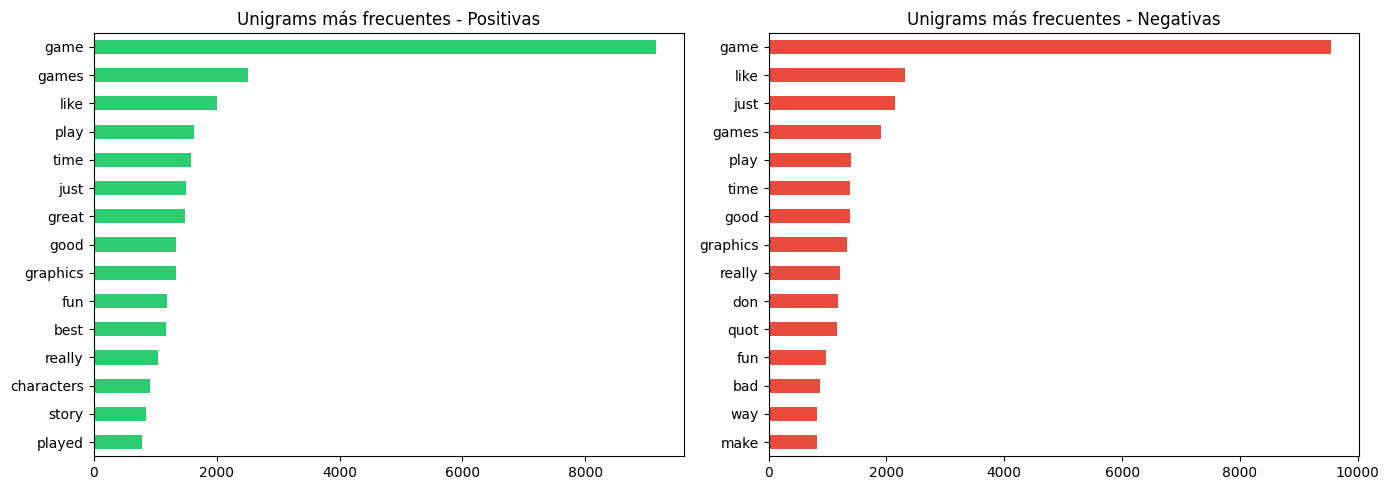

In [ ]:
# Unigrams
cv_pos = CountVectorizer(ngram_range=(1,1), stop_words='english', max_features=5000)
cv_neg = CountVectorizer(ngram_range=(1,1), stop_words='english', max_features=5000)

freq_pos = pd.Series(cv_pos.fit_transform(corpus_pos).toarray().sum(axis=0),
                     index=cv_pos.get_feature_names_out()).nlargest(15)
freq_neg = pd.Series(cv_neg.fit_transform(corpus_neg).toarray().sum(axis=0),
                     index=cv_neg.get_feature_names_out()).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
freq_pos.sort_values().plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Unigrams más frecuentes - Positivas')
freq_neg.sort_values().plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Unigrams más frecuentes - Negativas')
plt.tight_layout()
plt.show()

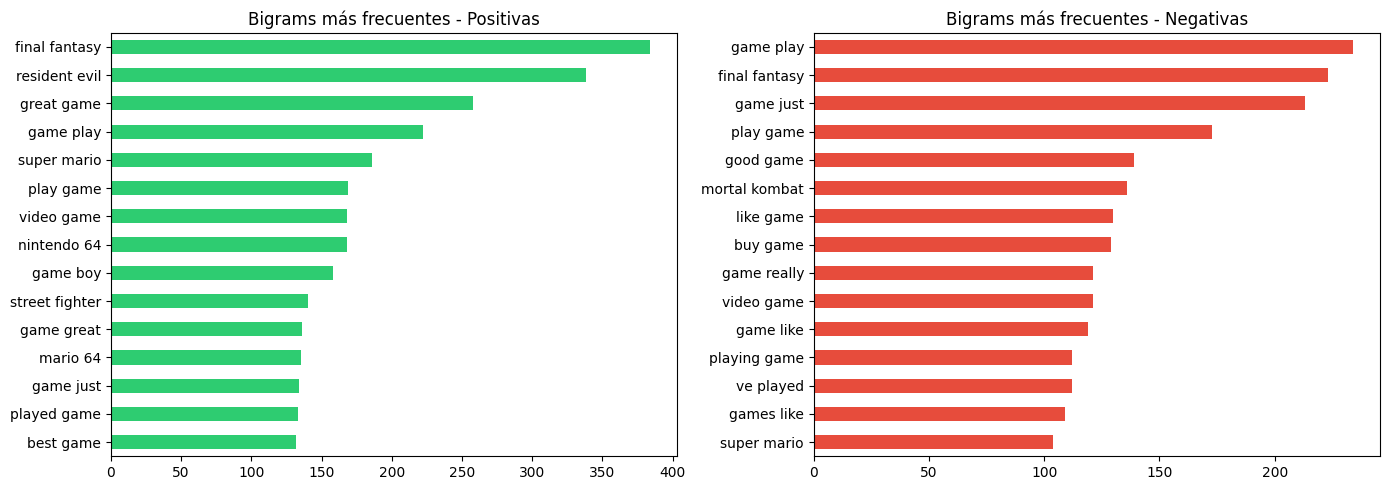

In [ ]:
# Bigrams
cv_pos_bi = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=5000)
cv_neg_bi = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=5000)

freq_pos_bi = pd.Series(cv_pos_bi.fit_transform(corpus_pos).toarray().sum(axis=0),
                        index=cv_pos_bi.get_feature_names_out()).nlargest(15)
freq_neg_bi = pd.Series(cv_neg_bi.fit_transform(corpus_neg).toarray().sum(axis=0),
                        index=cv_neg_bi.get_feature_names_out()).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
freq_pos_bi.sort_values().plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Bigrams más frecuentes - Positivas')
freq_neg_bi.sort_values().plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Bigrams más frecuentes - Negativas')
plt.tight_layout()
plt.show()

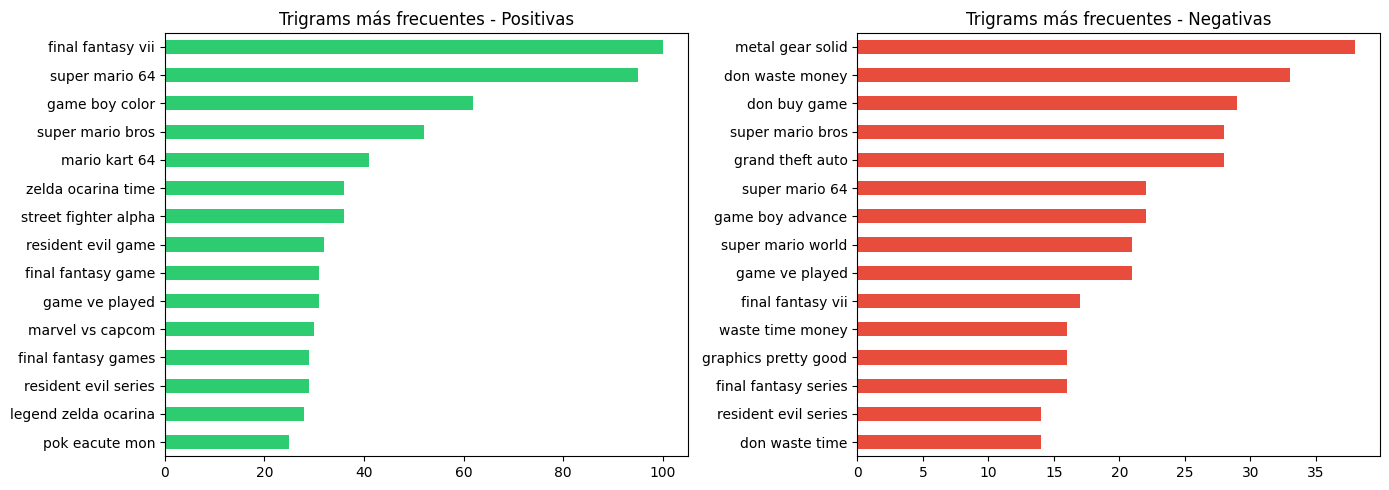

In [ ]:
# Trigrams
cv_pos_tri = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=5000)
cv_neg_tri = CountVectorizer(ngram_range=(3,3), stop_words='english', max_features=5000)

freq_pos_tri = pd.Series(cv_pos_tri.fit_transform(corpus_pos).toarray().sum(axis=0),
                         index=cv_pos_tri.get_feature_names_out()).nlargest(15)
freq_neg_tri = pd.Series(cv_neg_tri.fit_transform(corpus_neg).toarray().sum(axis=0),
                         index=cv_neg_tri.get_feature_names_out()).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
freq_pos_tri.sort_values().plot(kind='barh', ax=axes[0], color='#2ecc71')
axes[0].set_title('Trigrams más frecuentes - Positivas')
freq_neg_tri.sort_values().plot(kind='barh', ax=axes[1], color='#e74c3c')
axes[1].set_title('Trigrams más frecuentes - Negativas')
plt.tight_layout()
plt.show()

## 2.5 Nubes de palabras

In [ ]:
# Tabla para eliminar signos de puntuación.
table = str.maketrans('', '', string.punctuation)

# Junto todos los textos de cada clase en un string.
text_pos = ' '.join(corpus_pos).lower().translate(table)
text_neg = ' '.join(corpus_neg).lower().translate(table)

# Elimino acentos, por si hubiera alguno.
text_pos = unicodedata.normalize('NFKD', text_pos).encode('ascii', 'ignore').decode('utf-8', 'ignore')
text_neg = unicodedata.normalize('NFKD', text_neg).encode('ascii', 'ignore').decode('utf-8', 'ignore')

# Quito stopwords de la nube
sw_list = stopwords.words('english')

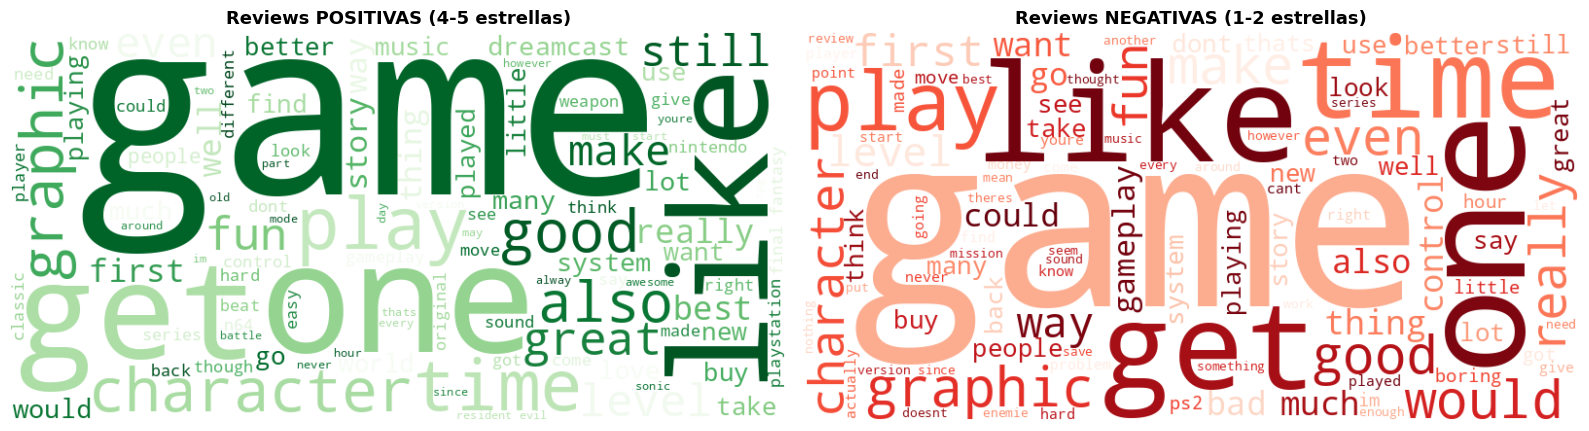

In [ ]:
# Pinto las nubes de palabras.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color='white',
                   colormap='Greens', max_words=100,
                   stopwords=sw_list).generate(text_pos)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Reviews POSITIVAS (4-5 estrellas)', fontsize=13, fontweight='bold')

wc_neg = WordCloud(width=800, height=400, background_color='white',
                   colormap='Reds', max_words=100,
                   stopwords=sw_list).generate(text_neg)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Reviews NEGATIVAS (1-2 estrellas)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 2.6 Distribución de longitud de las reviews

In [ ]:
# Miro el número de palabras que hay por review y su media por label.
df['num_words'] = df['text'].apply(lambda x: len(x.split()))

print(df.groupby('label')['num_words'].describe())

        count      mean         std  min    25%    50%    75%     max
label                                                                
0      2500.0  189.2740  207.643702  2.0  67.75  127.0  236.0  3151.0
1      2500.0  180.9324  216.062586  1.0  51.00  111.0  218.0  3062.0


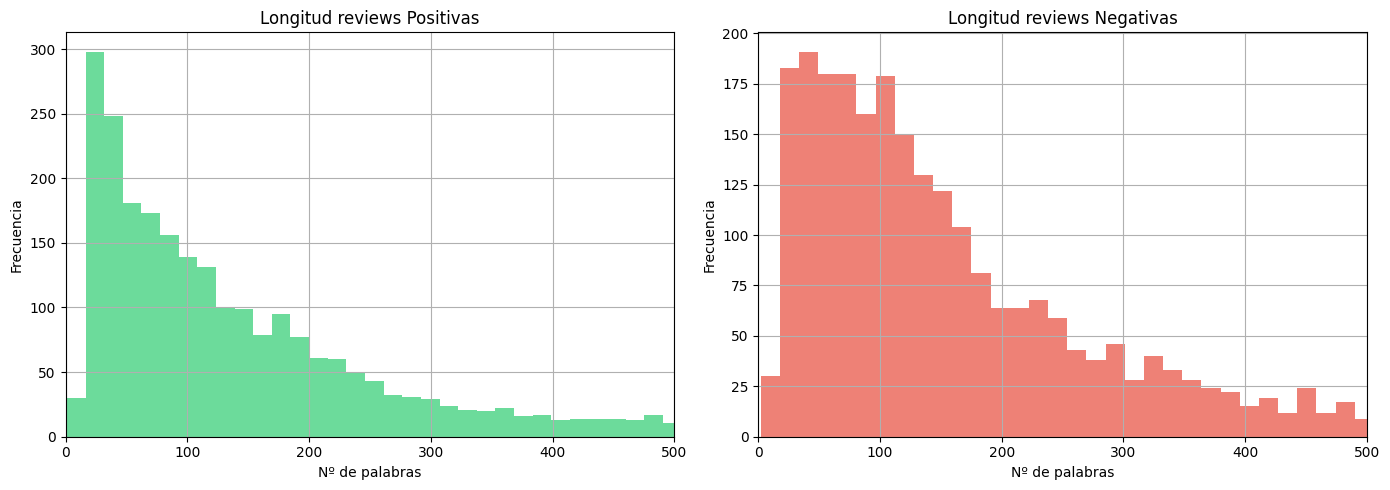

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['label'] == 1]['num_words'].hist(bins=200, ax=axes[0], color='#2ecc71', alpha=0.7)
axes[0].set_title('Longitud reviews Positivas')
axes[0].set_xlabel('Nº de palabras')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xlim(0, 500)

df[df['label'] == 0]['num_words'].hist(bins=200, ax=axes[1], color='#e74c3c', alpha=0.7)
axes[1].set_title('Longitud reviews Negativas')
axes[1].set_xlabel('Nº de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlim(0, 500)

plt.tight_layout()
plt.show()

## 2.7 Visualización 2D de Word Embeddings con Word2Vec
EntrenO Word2Vec y reduZCO con TSNE a 2D.  
Elijo 4 palabras clave y pinto sus 10 palabras más similares.


In [ ]:
# Tokenizo el corpus para Word2Vec: lista de listas de tokens
sentences = []
for text in df['text']:
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')
    text = text.lower()
    words = tokenizer.tokenize(text)
    sentences.append(words)

In [ ]:
import multiprocessing
cores = multiprocessing.cpu_count()

# Inicializo el modelo con los hiperparámetros
w2v_model = Word2Vec(min_count=5,
                     window=5,
                     vector_size=100,
                     sample=6e-5,
                     alpha=0.03,
                     min_alpha=0.0007,
                     negative=20,
                     workers=cores-1,
                     sg=1)

# Construyo el vocabulario
w2v_model.build_vocab(sentences, progress_per=10000)
print('Vocabulario compuesto por {} palabras'.format(len(w2v_model.wv.key_to_index)))

# Entreno el modelo.
w2v_model.train(sentences, total_examples=w2v_model.corpus_count, epochs=5)# Epochs 5, suficiente para mi pequeño dataframe.
print(f'Vocabulario Word2Vec: {len(w2v_model.wv):,} palabras')

Vocabulario compuesto por 7744 palabras
Vocabulario Word2Vec: 7,744 palabras


In [ ]:
# Palabras más similares para 4 palabras clave del dominio
w2v_model.wv.most_similar(positive=['game']) #Palabra neutra

[('ive', 0.9034934043884277),
 ('dissapointing', 0.900478720664978),
 ('nonstop', 0.8976438045501709),
 ('cuz', 0.8968596458435059),
 ('snowboarding', 0.8939052224159241),
 ('appreciate', 0.8897109627723694),
 ('awsome', 0.8872109055519104),
 ('disagree', 0.8871266841888428),
 ('fell', 0.8869094848632812),
 ('gt3', 0.8861135840415955)]

In [ ]:
w2v_model.wv.most_similar(positive=['fun']) # Palabra positiva

[('addictive', 0.8894588947296143),
 ('entertaining', 0.8706257343292236),
 ('addicting', 0.8686133027076721),
 ('entertained', 0.8524905443191528),
 ('alot', 0.8434557318687439),
 ('awesome', 0.841318666934967),
 ('stuff', 0.837605357170105),
 ('dirt', 0.8349867463111877),
 ('thats', 0.8278117179870605),
 ('dissapointing', 0.8254970908164978)]

In [ ]:
w2v_model.wv.most_similar(positive=['terrible']) #Palabra negativa

[('horrible', 0.9541100263595581),
 ('awful', 0.920415461063385),
 ('horrid', 0.9188337326049805),
 ('suck', 0.9125404357910156),
 ('sucks', 0.8906025290489197),
 ('english', 0.8882051706314087),
 ('bad', 0.8854944705963135),
 ('alright', 0.8853211998939514),
 ('decent', 0.8828611969947815),
 ('pathetic', 0.8758077621459961)]

In [ ]:
w2v_model.wv.most_similar(positive=['controller']) #Palabra neutra

[('comfortable', 0.9385684728622437),
 ('controllers', 0.9208402037620544),
 ('analog', 0.893759548664093),
 ('joystick', 0.8810965418815613),
 ('slot', 0.8585838079452515),
 ('stick', 0.8566920161247253),
 ('cord', 0.8524089455604553),
 ('triggers', 0.8482813239097595),
 ('modem', 0.8468567728996277),
 ('lcd', 0.8448688983917236)]

In [ ]:
keys = ['game', 'fun', 'terrible', 'controller']

embedding_clusters = []
word_clusters = []

for word in keys:
    embeddings = []
    words = []
    for similar_word, _ in w2v_model.wv.most_similar(word, topn=10):
        words.append(similar_word)
        embeddings.append(w2v_model.wv[similar_word])
    embedding_clusters.append(embeddings)
    word_clusters.append(words)

print(word_clusters)

[['ive', 'dissapointing', 'nonstop', 'cuz', 'snowboarding', 'appreciate', 'awsome', 'disagree', 'fell', 'gt3'], ['addictive', 'entertaining', 'addicting', 'entertained', 'alot', 'awesome', 'stuff', 'dirt', 'thats', 'dissapointing'], ['horrible', 'awful', 'horrid', 'suck', 'sucks', 'english', 'bad', 'alright', 'decent', 'pathetic'], ['comfortable', 'controllers', 'analog', 'joystick', 'slot', 'stick', 'cord', 'triggers', 'modem', 'lcd']]


In [ ]:
# Reduzco dimensionalidad a 2D con TSNE.
tsne_model_2d = TSNE(perplexity=15, n_components=2, init='pca', n_iter=3500, random_state=32)

embedding_clusters = np.array(embedding_clusters)
n, m, k = embedding_clusters.shape

embeddings_2d = np.array(tsne_model_2d.fit_transform(embedding_clusters.reshape(n * m, k))).reshape(n, m, 2)

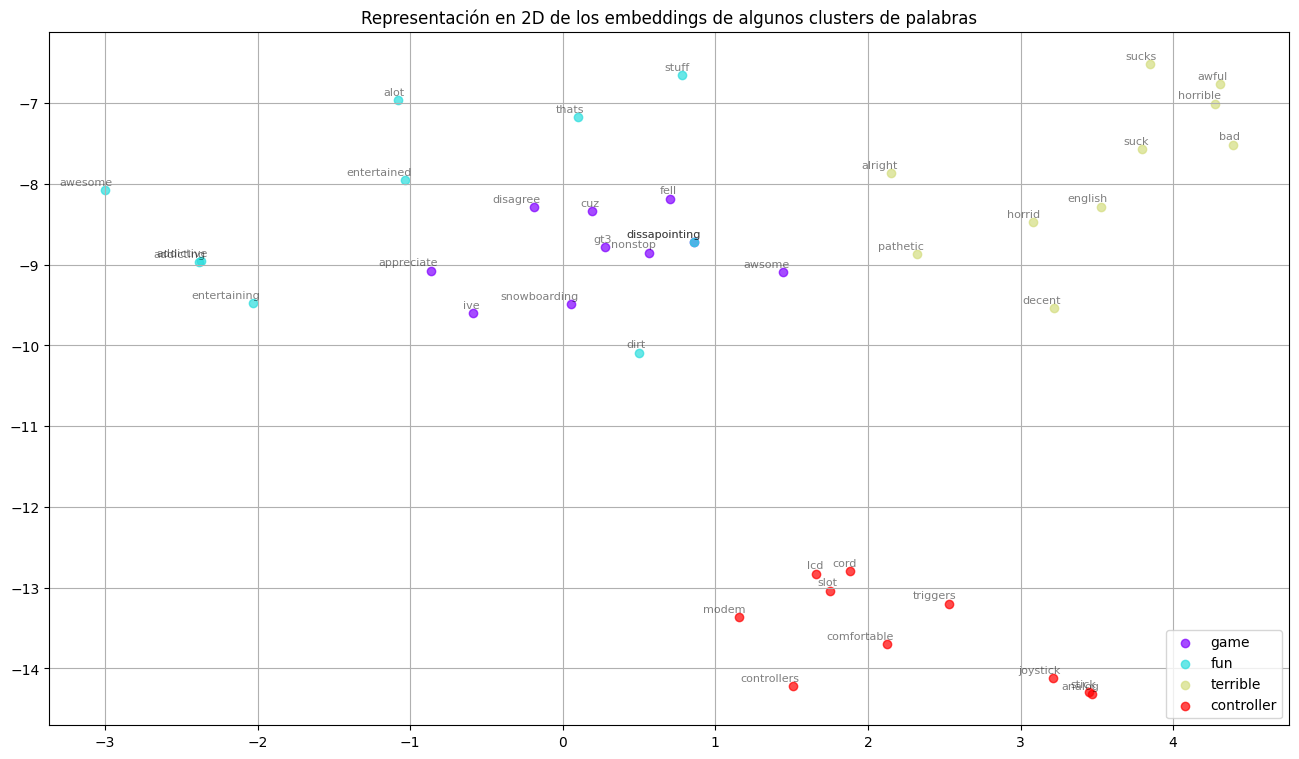

In [ ]:
# Visualización
def tsne_plot_similar_words(labels, embedding_clusters, word_clusters, a=0.7):
    plt.figure(figsize=(16, 9))
    colors = cm.rainbow(np.linspace(0, 1, len(labels)))
    for label, embeddings, words, color in zip(labels, embedding_clusters, word_clusters, colors):
        x = embeddings[:, 0]
        y = embeddings[:, 1]
        plt.scatter(x, y, c=[color], alpha=a, label=label)
        for i, word in enumerate(words):
            plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2),
                         textcoords='offset points', ha='right', va='bottom', size=8)
    plt.legend(loc=4)
    plt.grid(True)
    plt.title('Representación en 2D de los embeddings de algunos clusters de palabras')
    plt.show()

tsne_plot_similar_words(keys, embeddings_2d, word_clusters)

## 2.7 Conclusiones de la exploración
#Vocabulario

El top 20 son todas stopwords (the, and, to, a...) — queda claro que eliminarlas es el primer paso del preprocesado.

#Distribución de ratings

Dentro de cada clase no hay distribución uniforme: las negativas tienen más reviews de 2 estrellas que de 1, y las positivas tiran mucho hacia 5 estrellas. Tiene sentido, es lo que hay en el dataset original.

#Nubes de palabras

Positivas y negativas comparten palabras muy genéricas (game, time, play, get), lo que va a dificultar la discriminación si no preprocesamos
Las negativas sí muestran algunos términos con señal real: bad, boring, control, problem

#Longitud de reviews

Negativas: media 189 palabras, máximo 3151
Positivas: media 180 palabras, máximo 3062
La diferencia entre clases es pequeña. Sí hay outliers extremos (reviews de más de 3000 palabras) que habría que valorar truncar en el preprocesado

#Word2Vec + TSNE

most_similar('game') devuelve basura: definetly, infact, cuz, sooooo — el modelo está aprendiendo sobre texto sucio, lo que confirma que hay que preprocesar antes de entrenar embeddings
Los clusters de fun y terrible se separan bien en el gráfico, hay señal semántica útil
game y controller aparecen mezclados, lógico porque son palabras neutras que salen en reviews de ambas clases
